In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [104]:
df = pd.read_csv('C:\\Users\\Tanuja\\OneDrive\\Desktop\\codsoft\\Task2\\IMDb Movies India.csv', encoding='latin1')

In [103]:
df.info

<bound method DataFrame.info of                                      Name    Year Duration            Genre  \
0                                             NaN      NaN            Drama   
1      #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                             #Homecoming  (2021)   90 min   Drama, Musical   
3                                 #Yaaram  (2019)  110 min  Comedy, Romance   
4                       ...And Once Again  (2010)  105 min            Drama   
...                                   ...     ...      ...              ...   
15504                 Zulm Ko Jala Doonga  (1988)      NaN           Action   
15505                               Zulmi  (1999)  129 min    Action, Drama   
15506                           Zulmi Raj  (2005)      NaN           Action   
15507                       Zulmi Shikari  (1988)      NaN           Action   
15508                        Zulm-O-Sitam  (1998)  130 min    Action, Drama   

       Rating Votes

In [105]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [106]:
df.head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,(2008),59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [107]:
df.dropna(subset=df.columns[1:9],how='all',inplace=True)

In [108]:
df.dropna(subset=['Name','Year'],how='all',inplace=True)

In [109]:
df.drop_duplicates(['Name','Year'],keep='first',inplace=True)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15477 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15477 non-null  object 
 1   Year      14958 non-null  object 
 2   Duration  7235 non-null   object 
 3   Genre     13614 non-null  object 
 4   Rating    7915 non-null   float64
 5   Votes     7916 non-null   object 
 6   Director  14962 non-null  object 
 7   Actor 1   13875 non-null  object 
 8   Actor 2   13110 non-null  object 
 9   Actor 3   12355 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.3+ MB


In [111]:
df.dropna(subset=['Year'],inplace=True)

In [112]:
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd

# Assuming movie_file is your DataFrame loaded from a file or other source
# movie_file = pd.read_csv('path_to_your_file.csv')  # Example of loading data from a CSV file

# Check if movie_file is loaded and 'Year' column exists
if 'movie_file' in locals() and 'Year' in movie_file.columns:
    # Handle NaN values if present and convert 'Year' column to integers
    movie_file = movie_file.dropna(subset=['Year'])
    try:
        movie_file['Year'] = movie_file['Year'].astype(int)
    except ValueError as e:
        print(f"Error converting 'Year' to integers: {e}")
        print("Please check the 'Year' column for non-numeric values.")
    
    # Get annual movie release counts and sort by year
    release_counts = movie_file['Year'].value_counts().sort_index()

    # Plot the data
    ax = sb.lineplot(x=release_counts.index, y=release_counts.values)
    darkgrid_positions = range(min(movie_file['Year']), max(movie_file['Year']) + 1, 5)

    # Set title and labels
    ax.set_title("Annual Movie Release Counts Over Time")
    ax.set_xlabel("Years")
    ax.set_ylabel("Count")

    # Set the x-ticks and their labels
    ax.set_xticks(darkgrid_positions)
    ax.set_xticklabels(darkgrid_positions, rotation=90)

    # Show the plot
    plt.show()
else:
    print("The 'Year' column is not present in the DataFrame or 'movie_file' is not defined.")

The 'Year' column is not present in the DataFrame or 'movie_file' is not defined.


In [113]:
df['Duration']=df['Duration'].str.extract(r'([0-9]+)',expand=False)

In [114]:
def get_mode_with_default(x):
    mode_result = x.mode()
    if not mode_result.empty:
        return mode_result[0]
    else:
        return 'unknown'  

df['Actor 1']=df['Actor 1'].fillna(df.groupby('Year')['Actor 1'].transform(get_mode_with_default))
df['Actor 2']=df['Actor 2'].fillna(df.groupby('Year')['Actor 2'].transform(get_mode_with_default))
df['Actor 3']=df['Actor 3'].fillna(df.groupby('Year')['Actor 3'].transform(get_mode_with_default))

In [115]:
df['Director']=df.groupby(['Year','Actor 1','Actor 2','Actor 3'])['Director'].transform(get_mode_with_default)

In [116]:
df['Duration']=pd.to_numeric(df['Duration'])

In [117]:
def get_mean_with_default(x):
    mean_result = x.mean()
    if not math.isnan(mean_result):        
            return round(mean_result)
    else:
        return 0
df['Duration']=df.groupby(['Year','Director','Actor 1','Actor 2','Actor 3'])['Duration'].transform(get_mean_with_default)

In [119]:
df['Votes']=df['Votes'].str.extract(r'([0-9]+)',expand=False)
df['Votes']=pd.to_numeric(df['Votes'])

In [120]:
df['Votes']=df.groupby(['Year','Rating'])['Votes'].transform(lambda x:x.mean())

In [121]:
df['Votes']=df.groupby('Year')['Votes'].transform(lambda x:x.mean())

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14958 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      14958 non-null  object 
 1   Year      14958 non-null  object 
 2   Duration  14958 non-null  int64  
 3   Genre     13123 non-null  object 
 4   Rating    14947 non-null  float64
 5   Votes     14908 non-null  float64
 6   Director  14958 non-null  object 
 7   Actor 1   14958 non-null  object 
 8   Actor 2   14958 non-null  object 
 9   Actor 3   14958 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.3+ MB


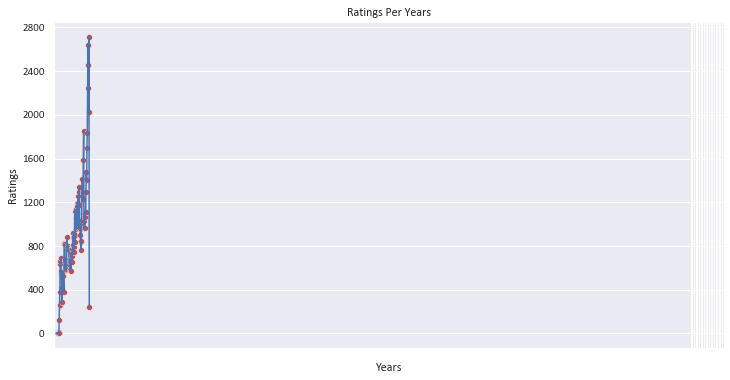

In [123]:
rating_sum=df.groupby('Year')['Rating'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='Year',y='Rating',data=rating_sum)
sns.scatterplot(x='Year',y='Rating',data=rating_sum,color='r')
plt.yticks(np.arange(0,3000,400))
plt.xticks(np.arange(1920,2025,5))
plt.ylabel('Ratings')
plt.xlabel('Years')
plt.title('Ratings Per Years')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

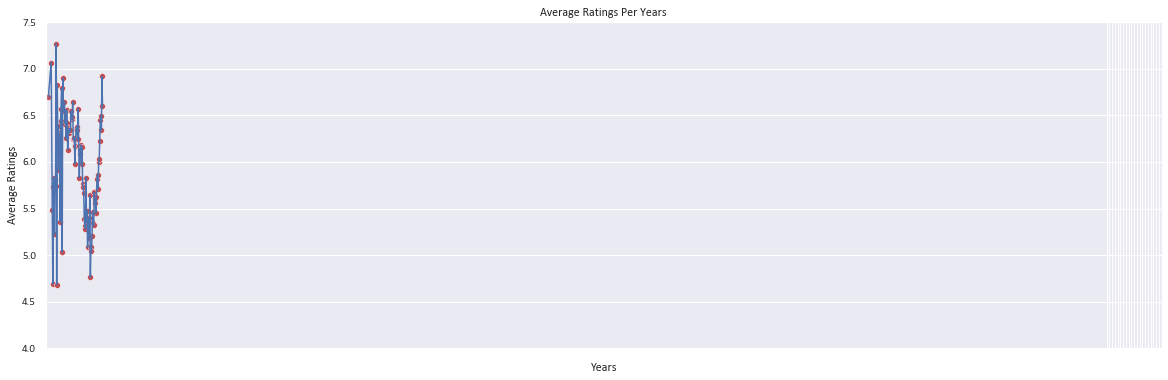

In [124]:
rating_avg=df.groupby('Year')['Rating'].mean().reset_index()

plt.figure(figsize=(20,6))
sns.lineplot(x='Year',y='Rating',data=rating_avg)
sns.scatterplot(x='Year',y='Rating',data=rating_avg,color='r')
plt.yticks(np.arange(4,8,0.5))
plt.xticks(np.arange(1920,2025,5))
plt.ylabel('Average Ratings')
plt.xlabel('Years')
plt.title('Average Ratings Per Years')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

Correlation Of Duration And Rating is -0.07511162035794011


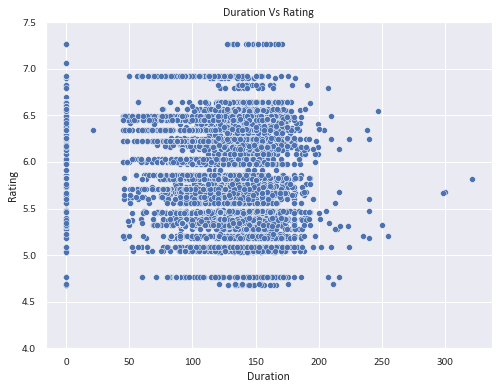

In [125]:
corr_leng_rat=df['Duration'].corr(df['Rating'])
print(f"Correlation Of Duration And Rating is {corr_leng_rat}")
#show there is no impact of duration on rating

plt.figure(figsize=(8,6))
sns.scatterplot(x='Duration',y='Rating',data=df)
plt.xlabel('Duration')
plt.ylabel('Rating')
plt.title('Duration Vs Rating')
plt.yticks(np.arange(4,8,0.5))
plt.show()

In [126]:
overall=df.nlargest(10,'Rating')
overall=overall.reset_index(drop=True)
print("Top 10 Movies Overall:")
overall

Top 10 Movies Overall:


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,Abhagin,(1938),151,NaN,7.266085,9.555556,Prafulla Roy,Molina Devi,Prithviraj Kapoor,Vijay Kumar
1,Abhilasha,(1938),134,NaN,7.266085,9.555556,Zia Sarhadi,Mahendra Thakore,M. Kumar,Bibbo
2,Adhikar,(1938),132,NaN,7.266085,9.555556,P.C. Barua,P.C. Barua,Jamuna,Pahadi Sanyal
3,Baazigar,(1938),152,NaN,7.266085,9.555556,Mohan Dayaram Bhavnani,K.L. Saigal,Ashok Kumar,Bibbo
4,Baghban,(1938),159,Drama,7.266085,9.555556,Abdul Rashid Kardar,Bimla Kumari,B. Nandrekar,Sitara Devi
5,Bahadur Kisan,(1938),0,NaN,7.266085,9.555556,Master Bhagwan,Chandrarao,Chandrarao,Hansa Wadkar
6,Ban Ki Chidiya,(1938),0,Action,7.266085,9.555556,Jayant Desai,Madhuri,Eddie Billimoria,Ishwarlal
7,Banke Sanvaria,(1938),0,NaN,7.266085,9.555556,Nanubhai Vakil,Navinchandra,Vatsala Kumthekar,Yasmin
8,Bhabi,(1938),0,"Drama, Family",7.266085,9.555556,Franz Osten,Renuka Devi,Paidi Jairaj,Meera
9,Bhedi Trishul,(1938),0,NaN,7.266085,9.555556,A.M. Khan,Ameena,Ansari,Kamia


In [127]:
rat_bool=df['Rating']>=6
vot_bool=df['Votes']>110
pop_df=df[vot_bool & rat_bool]
pop_df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109,Drama,6.489797,121.779116,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90,"Drama, Musical",6.917411,116.666667,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110,"Comedy, Romance",6.489797,121.779116,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
15,102 Not Out,(2018),102,"Comedy, Drama",6.450093,111.070175,Umesh Shukla,Amitabh Bachchan,Rishi Kapoor,Vijay Raaz
20,12 Bulbule,(2021),0,"Comedy, Drama, Family",6.917411,116.666667,Jagat Joon,Sonu Sonkar,Sunita Verman,Anubhav Dixit
...,...,...,...,...,...,...,...,...,...,...
15426,Zero,(2018),164,"Comedy, Drama, Romance",6.450093,111.070175,Aanand L. Rai,Shah Rukh Khan,Anushka Sharma,Katrina Kaif
15479,Zindagi Tumse,(2019),120,Family,6.489797,121.779116,Tariq Bhat,Sadhana Singh,Guddi Maruti,Rajesh Puri
15480,Zindagi Unlimited,(2021),105,NaN,6.917411,116.666667,Vipin Agnihotri,Amit Pandey,Kanchi Rohela,Kritika Sanghavi
15484,Zinga,(2021),0,"Adventure, Fantasy, Sci-Fi",6.917411,116.666667,Jaishankar Chigurula,Sri Ram,Devan Sanjeev,Kasu Naveen Kumar


In [128]:
df.dropna(inplace=True)
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

TypeError: Vertical orientation requires numeric `y` variable.

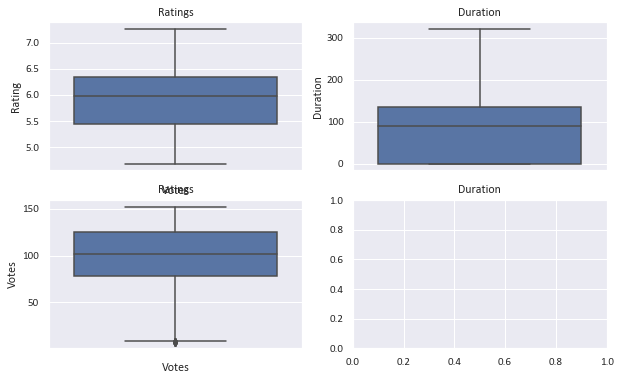

In [130]:
#df.reset_index()
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(10,6))

sns.boxplot(data=df,y='Rating',ax=ax[0][0])
ax[0][0].set_title('Ratings')
ax[0][0].set_xlabel('Ratings')

sns.boxplot(data=df,y='Duration',ax=ax[0][1])
ax[0][1].set_title('Duration')
ax[0][1].set_xlabel('Duration')

sns.boxplot(data=df,y='Votes',ax=ax[1][0])
ax[1][0].set_title('Votes')
ax[1][0].set_xlabel('Votes')

sns.boxplot(data=df,y='Year',ax=ax[1][1])
ax[1][1].set_title('Years')
ax[1][1].set_xlabel('Years')

plt.tight_layout()

plt.show()


In [131]:
def out(df,col,dis):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-(iqr*dis)
    upper=q3+(iqr*dis)
    return lower,upper

In [132]:
votes_low,votes_up=out(df,'Votes',1.5)

In [133]:
vote_out_count=(df['Votes'] > votes_up) | (df['Votes'] < votes_low)

In [134]:
df['Votes'][vote_out_count].count()

12

In [135]:
df=df[(df['Votes']>votes_low) & (df['Votes']<votes_up)]


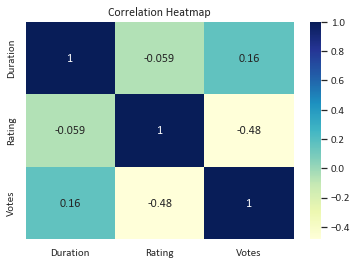

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Identify numeric columns for correlation matrix
numeric_cols = df.select_dtypes(include=np.number).columns

# Create a heatmap of the correlation matrix for numeric columns only
sns.heatmap(df[numeric_cols].corr(), cmap='YlGnBu', annot=True)

plt.title('Correlation Heatmap')
plt.show()

In [141]:
from sklearn.preprocessing import LabelEncoder
LB=LabelEncoder()
df['Name']=LB.fit_transform(df['Name'])
df['Genre']=LB.fit_transform(df['Genre'])
df['Director']=LB.fit_transform(df['Director'])
df['Actor 1']=LB.fit_transform(df['Actor 1'])
df['Actor 2']=LB.fit_transform(df['Actor 2'])
df['Actor 3']=LB.fit_transform(df['Actor 3'])

In [142]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [143]:
from sklearn.model_selection import train_test_split
x=df.drop('Rating',axis=1)
y=df['Rating']

In [144]:
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.3,random_state=42)

In [150]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [152]:
cv2=cross_val_score(LGBMR,x,y,cv=kf,n_jobs=-1)
print('Accuracy : ',cv2.mean()*100)

Accuracy :  nan


c:\Users\Tanuja\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning:


10 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Tanuja\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Tanuja\anaconda3\lib\site-packages\lightgbm\sklearn.py", line 1173, in fit
    super().fit(
  File "c:\Users\Tanuja\anaconda3\lib\site-packages\lightgbm\sklearn.py", line 954, in fit
    self._Booster = train(
  File "c:\Users\Tanuja\anaconda3\lib\site-packages\lightgbm\engine.py", line 28